# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# 2. Load Dataset

In [3]:
df = pd.read_csv("retail_store_sales_cleaned.csv")

# 3. Univariate Analysis
Explore each variable individually.

### Univariate Analysis of Sales
We examine the distribution of sales to identify skewness, outliers, and central tendency.

In [32]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Revenue,Month,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,185.0,4,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,261.0,7,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,43.0,10,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,Unknown,247.5,5,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,87.5,10,2022


In [34]:
# Numerical columns

num_cols = ['Price Per Unit','Quantity','Revenue','Month','Year']
df[num_cols].describe()

,Price Per Unit,Quantity,Revenue,Month,Year
count,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,130.114950,6.366441,2023.042386
std,10.480413,2.790160,92.327187,3.503156,0.855581
min,5.000000,1.000000,5.000000,1.000000,2022.000000
25%,14.000000,3.000000,55.000000,3.000000,2022.000000
50%,23.000000,6.000000,111.000000,6.000000,2023.000000
75%,32.000000,8.000000,192.000000,9.000000,2024.000000
max,41.000000,10.000000,410.000000,12.000000,2025.000000


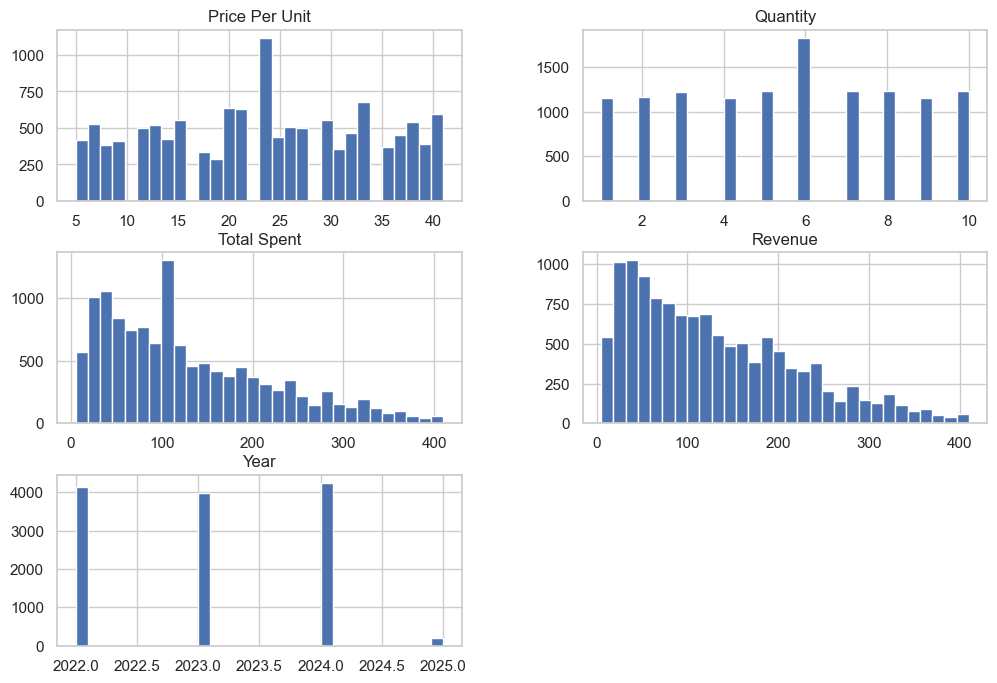

In [5]:
# Histograms

df[num_cols].hist(bins=30, figsize=(12,8))
plt.show()

Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64


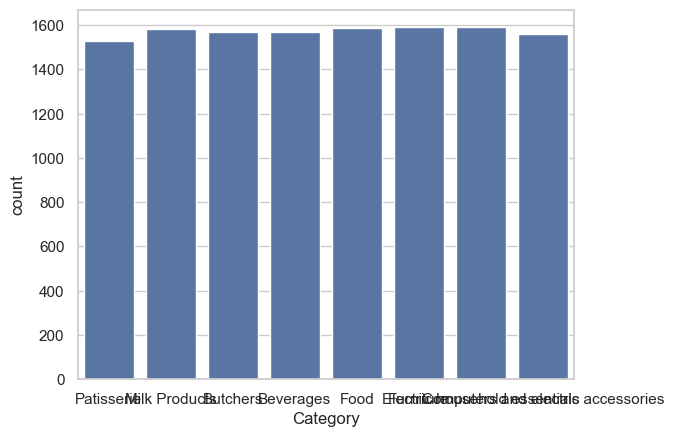

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64


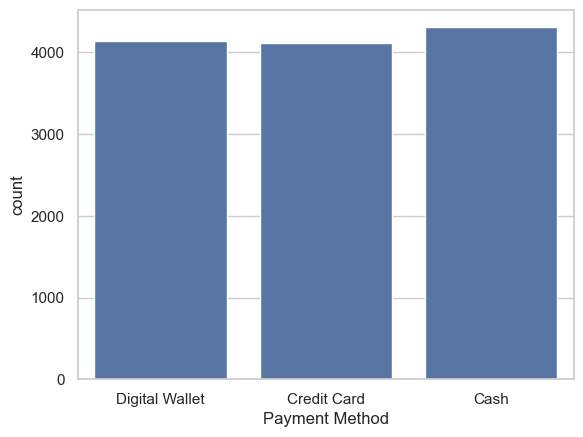

Location
Online      6354
In-store    6221
Name: count, dtype: int64


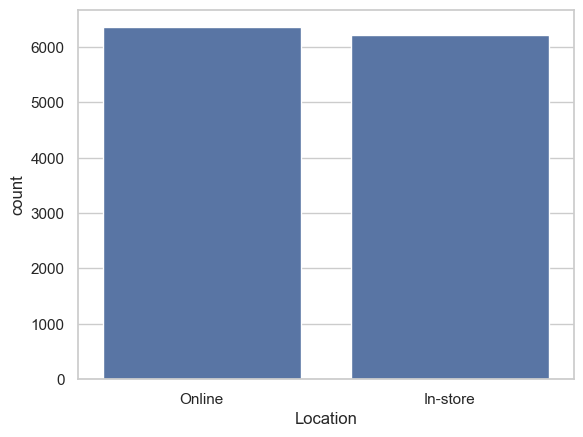

Month
1     1361
7     1089
8     1039
6     1038
5     1033
12    1033
9     1021
3     1019
11    1003
4      996
10     978
2      965
Name: count, dtype: int64


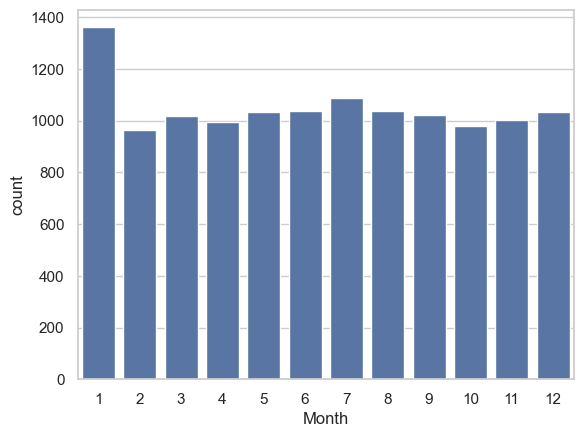

Year
2024    4241
2022    4134
2023    3987
2025     213
Name: count, dtype: int64


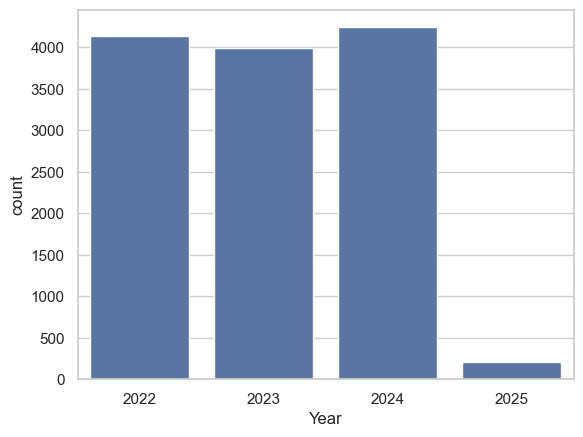

In [6]:
# Categorical columns

cat_cols = ['Category','Payment Method','Location','Month','Year']
for col in cat_cols:
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.show()

# 4. Bivariate Analysis
Look at relationships between two variables.

In [7]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Revenue,Month,Year
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,185.0,4,2024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,261.0,7,2023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,43.0,10,2022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,Unknown,247.5,5,2022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,87.5,10,2022


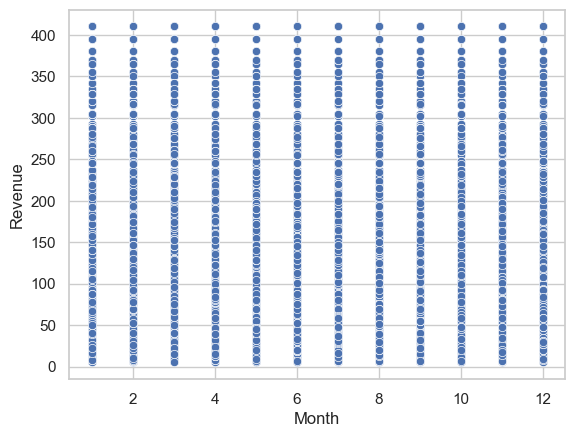

In [25]:
# Numerical vs Numerical
sns.scatterplot(x='Month', y='Revenue', data=df)
plt.show()

In [26]:
print(df[['Month','Revenue','Year']].corr())

            Month   Revenue      Year
Month    1.000000 -0.007684 -0.046390
Revenue -0.007684  1.000000  0.000482
Year    -0.046390  0.000482  1.000000


Category
Beverages                             131.855456
Butchers                              138.646046
Computers and electric accessories    129.880295
Electric household essentials         134.130421
Food                                  129.523929
Furniture                             129.053426
Milk Products                         120.503472
Patisserie                            127.317081
Name: Revenue, dtype: float64


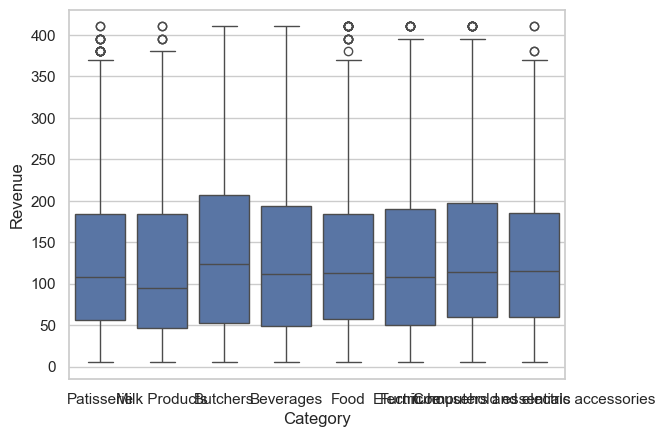

In [27]:
# Categorical vs Numerical

print(df.groupby('Category')['Revenue'].mean())
sns.boxplot(x='Category', y='Revenue', data=df)
plt.show()

In [29]:
# Categorical vs Categorical

pd.crosstab(df['Customer ID'], df['Category'])
pivot = df.pivot_table(values='Revenue', index='Category', columns='Customer ID', aggfunc='sum')
print(pivot)

Customer ID                         CUST_01  CUST_02  CUST_03  CUST_04  \
Category                                                                 
Beverages                            7023.0   8717.5   9017.0   9251.0   
Butchers                             8788.0   8412.0   8615.0  10826.0   
Computers and electric accessories   8642.0   5427.0   7397.0   9930.5   
Electric household essentials        7515.0  10090.0   6718.5   9087.0   
Food                                 8589.5   9014.0   7373.5   5747.5   
Furniture                            9693.5   9793.0   7881.0   6780.5   
Milk Products                        5435.0   7236.5   8359.0   7748.0   
Patisserie                           6716.0   6647.5   8027.0   4951.5   

Customer ID                         CUST_05  CUST_06  CUST_07  CUST_08  \
Category                                                                 
Beverages                           11258.5   6449.0   7538.5   9413.5   
Butchers                             

# 5. Multivariate Analysis

In [12]:
# Pivot table with multiple dimensions
# more than two variables

pivot_multi = df.pivot_table(values='Revenue', index='Location', columns='Payment Method', aggfunc='mean')
print(pivot_multi)

Payment Method        Cash  Credit Card  Digital Wallet
Location                                               
In-store        129.498129   128.855198      129.857489
Online          133.494015   129.976440      128.839741


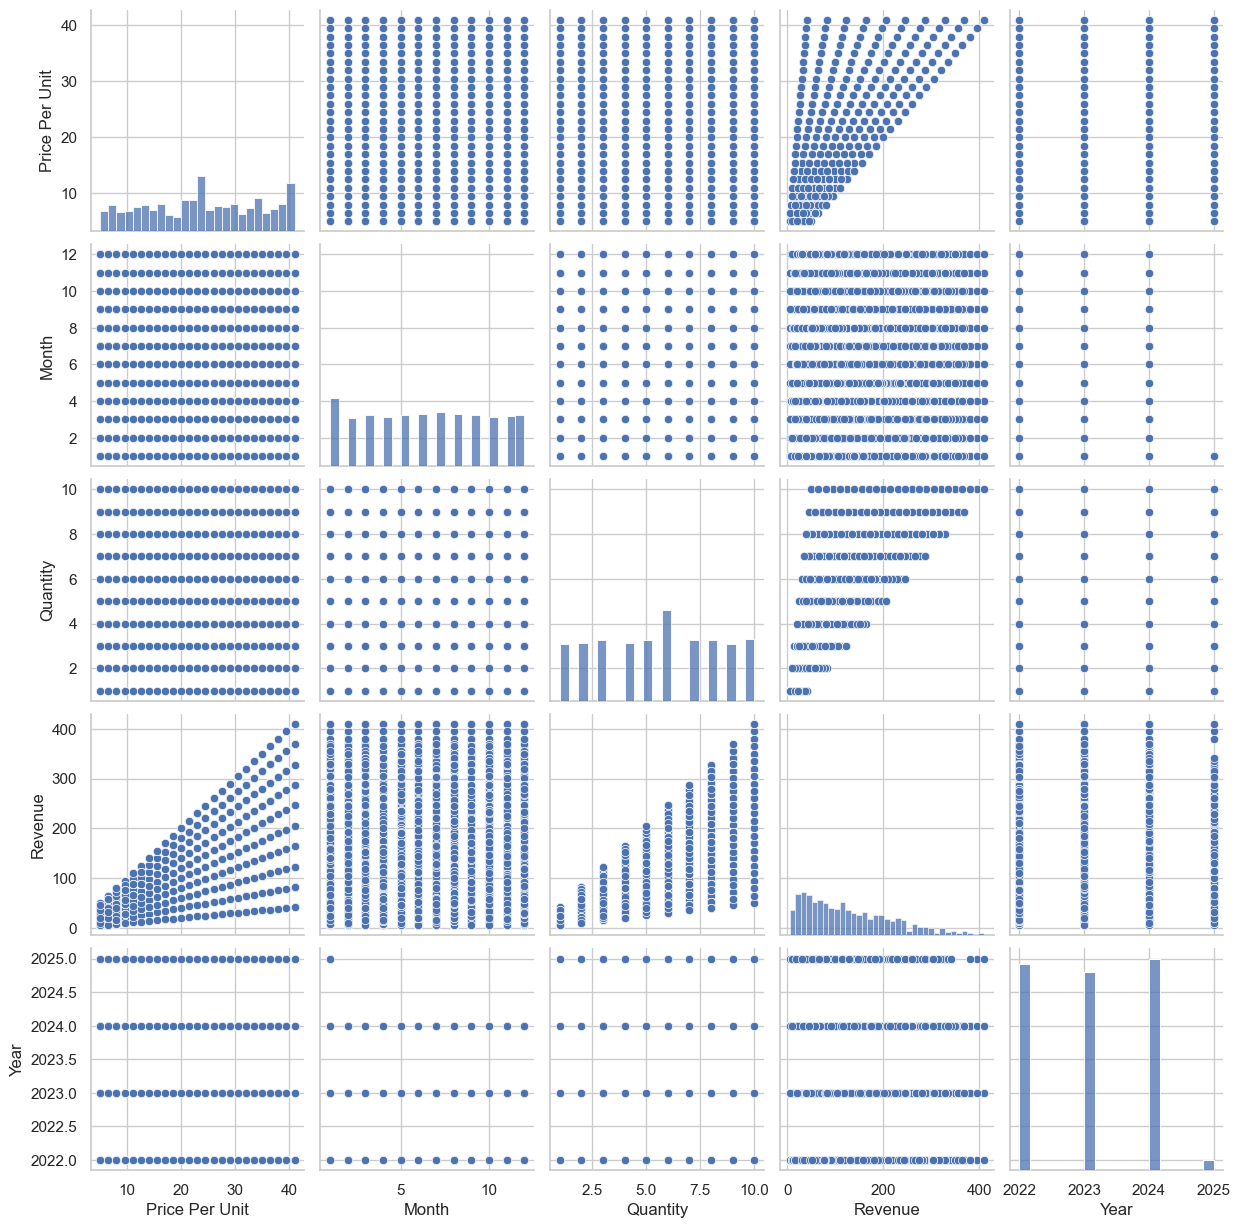

In [30]:
# Pairplot for numerical features

sns.pairplot(df[['Price Per Unit','Month','Quantity','Revenue','Year']])
plt.show()

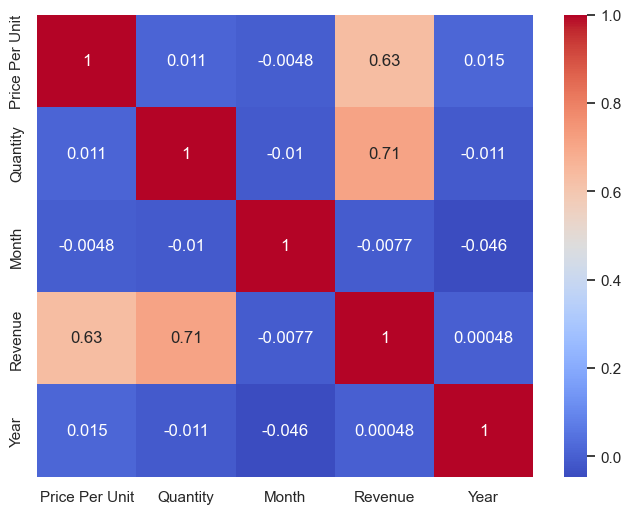

In [35]:
# Correlation heatmap

num_cols = ['Price Per Unit','Quantity','Month','Revenue','Year']
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# 6. Statistical Summaries

In [14]:
# Group-level summaries

print(df.groupby('Location')['Revenue'].agg(['mean','median','std','sum']))

print(df.groupby('Category')['Total Spent'].agg(['mean','median','std','sum']))

                mean  median        std       sum
Location                                         
In-store  129.408536   110.0  92.427082  805050.5
Online    130.806579   111.0  92.231309  831145.0
                                          mean  median        std       sum
Category                                                                   
Beverages                           130.664327   108.5  96.336651  204751.0
Butchers                            137.710459   112.0  98.221672  215930.0
Computers and electric accessories  128.036585   108.5  86.466197  199481.0
Electric household essentials       133.218730   108.5  93.498905  211951.0
Food                                128.211902   108.5  88.375104  203600.5
Furniture                           127.260214   108.5  96.286352  202471.0
Milk Products                       118.570391    98.0  90.791222  187815.5
Patisserie                          125.395942   108.5  88.628360  191605.0


# 📊 Summary of Findings
### • 	Price Per Unit & Quantity:
Prices cluster around mid-range values (~25), while quantities peak around 6 units.
### • 	Total Spent & Revenue:
Both distributions are skewed toward lower values, with most transactions generating modest revenue (~50–100).
### • 	Yearly Trends:
2022–2024 show consistently high transaction counts, but 2025 drops sharply, suggesting incomplete data or a real decline.
### • 	Categories:
Product categories (Food, Electronics, Beverages, etc.) have nearly uniform item counts (~1500 each).
### • 	Payment Methods: 
Cash dominates, followed by Digital Wallet and Credit Card, which are nearly equal.
### • 	Location:
Online slightly surpasses In-store transactions, showing a tilt toward digital channels.
### • 	Monthly Trends:
January stands out with the highest activity (~1300), while other months remain steady (~950–1100).
### • 	Revenue by Category: 
Box plots reveal wide variation—some categories (e.g., Electronics, Computers) show higher revenue ranges, while others (e.g., Food, Patisserie) are lower.
### • 	Relationships (Pair Plot & Correlation Matrix):
• 	Strong positive correlation between Total Spent and Revenue (0.97).
• 	Quantity and Price Per Unit both drive spending and revenue.
• 	Year has negligible correlation with financial metrics, meaning time isn’t directly influencing values.


# 💡 Key Insights
### 1. 	Revenue Drivers:
• 	Spending and revenue are tightly linked, confirming that higher basket sizes (quantity × price) directly boost revenue.

• 	Categories like Electronics and Computers yield higher revenue per transaction, suggesting premium product impact.

### 2. 	Consumer Behavior:
• 	Cash remains the most popular payment method, but Digital Wallets are catching up—indicating a gradual digital adoption trend.

• 	Online transactions slightly outpace In-store, reinforcing the importance of e-commerce.

### 3. 	Seasonality:
• 	January shows a clear spike in activity, possibly due to holiday or new-year promotions.

• 	Other months remain stable, suggesting predictable demand outside seasonal peaks.

### 4. 	Yearly Drop in 2025:
• 	The sharp decline in 2025 could be due to incomplete data collection or a real downturn. This anomaly needs further investigation.

### 5. 	Strategic Opportunities:
• 	Focus marketing on high-revenue categories (Electronics, Computers).

• 	Encourage digital payments with promotions to accelerate wallet/credit adoption.

• 	Leverage January’s demand surge with targeted campaigns.

• 	Investigate 2025’s drop—if it’s real, corrective action is needed.